# Prediction check: kappa=0 (no lateral coupling) model

Same rest -> motion -> rest check as `07_v4_final_sweep_and_results.ipynb`,
now against the kappa=0 ablation checkpoint (best val loss 0.000021 @
epoch 157, vs. 0.0000118 for the coupled kappa=0.5 model). Same
architecture class otherwise (`LateralizedHopfModelVM` from
`sweep_train.py`), just `kappa=0.0`.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from sweep_train import LateralizedHopfModelVM, TrajectoryDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K0_DIR = Path.cwd().parent / "outputs_v4_kappa0"
PROJECT_ROOT = K0_DIR.parent

with open(K0_DIR / "metrics.json") as f:
    metrics = json.load(f)
print("Run metrics:", json.dumps(metrics, indent=2))

ckpt = torch.load(K0_DIR / "best_hopf_model.pt", map_location=device)
print(f"\nLoaded checkpoint from epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.8f}")

cfg = metrics["config"]
model = LateralizedHopfModelVM(
    n_osc_per_side=cfg["n_osc_per_side"], v_hidden=cfg["v_hidden"], dt=0.005, input_scaler=5.0,
    min_freq=8.0, max_freq=13.0, kappa=cfg["kappa"], readout_hidden=cfg["readout_hidden"],
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Model loaded (kappa =", model.kappa, ")")

Run metrics: {
  "best_val_loss": 2.0845075596298557e-05,
  "best_epoch": 157,
  "epochs_run": 207,
  "elapsed_sec": 5853.598164558411,
  "config": {
    "learning_rate": 0.001,
    "batch_size": 32,
    "kappa": 0.0,
    "n_osc_per_side": 50,
    "v_hidden": 32,
    "readout_hidden": 32,
    "teacher_forcing_end": 0.1,
    "seed": 42,
    "pad_pre": 20,
    "pad_post": 20
  }
}



Loaded checkpoint from epoch 157, val_loss=0.00002085
Model loaded (kappa = 0.0 )


In [2]:
def active_cols(traj):
    left_travel = np.linalg.norm(traj[-1, :2] - traj[0, :2])
    right_travel = np.linalg.norm(traj[-1, 2:] - traj[0, 2:])
    return slice(0, 2) if left_travel > right_travel else slice(2, 4)


def autoregressive_rollout(model, traj_gt, target, moving_flag, device):
    traj_gt = traj_gt.unsqueeze(0).to(device)
    target_b = target.unsqueeze(0).to(device)
    moving_b = moving_flag.unsqueeze(0).to(device)
    state = model.init_state(batch_size=1, device=device)
    prev = traj_gt[:, 0]
    preds = [prev]
    with torch.no_grad():
        for t in range(1, traj_gt.shape[1]):
            moving_t = moving_b[:, t:t + 1]
            inp = torch.cat([prev, target_b, moving_t], dim=1)
            pred, state = model.forward_step(inp, state)
            preds.append(pred)
            prev = pred
    return torch.cat(preds, dim=0).cpu().numpy()


dataset = TrajectoryDataset(PROJECT_ROOT, pad_pre=cfg["pad_pre"], pad_post=cfg["pad_post"])
train_size = int(0.8 * len(dataset)); val_size = len(dataset) - train_size
_, val_dataset = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(cfg["seed"]))
print(f"Validation set: {len(val_dataset)} trajectories, {val_dataset[0][0].shape[0]} timesteps each")

Validation set: 100 trajectories, 140 timesteps each


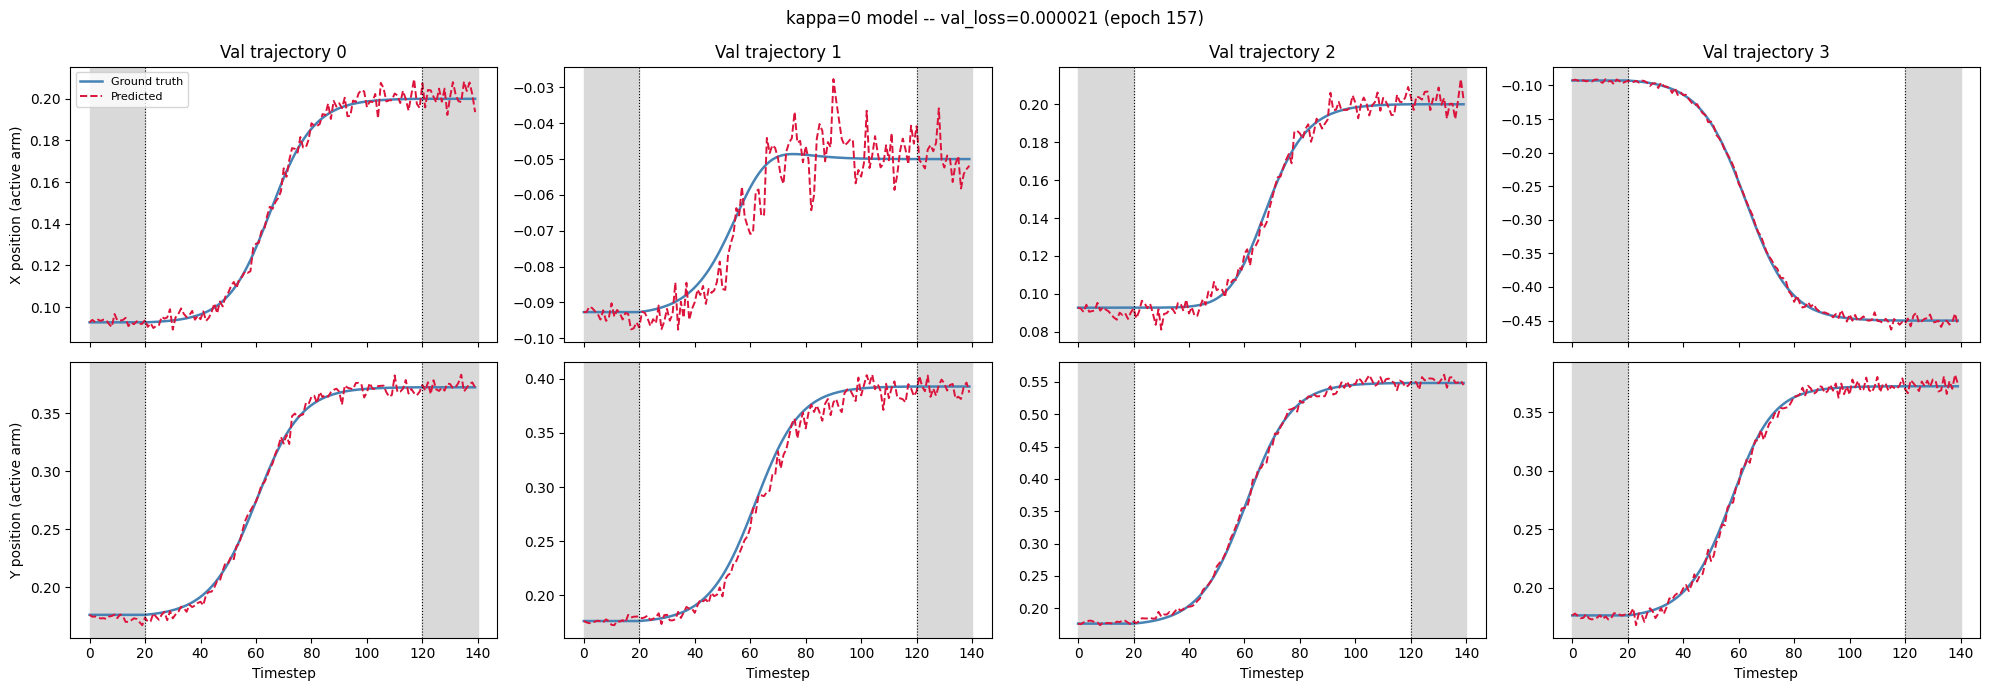

traj | rest-pre |x_err| |  motion mean err | rest-post |x_err|
   0 |          0.00120 |          0.00493 |           0.00418
   1 |          0.00157 |          0.01007 |           0.00351
   2 |          0.00264 |          0.00632 |           0.00419
   3 |          0.00173 |          0.00524 |           0.00470


In [3]:
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(5 * n_show, 7), sharex=True)
pad_pre, pad_post = dataset.pad_pre, dataset.pad_post
region_stats = []

for i in range(n_show):
    traj_gt, target, moving_flag, _ = val_dataset[i]
    gt_traj = traj_gt.numpy()
    pred_traj = autoregressive_rollout(model, traj_gt, target, moving_flag, device)
    cols = active_cols(gt_traj)
    mflag = moving_flag.numpy(); T = len(mflag)
    move_start = pad_pre; move_end = pad_pre + int(mflag.sum())

    for row, (label, coord_idx) in enumerate([("X position (active arm)", 0), ("Y position (active arm)", 1)]):
        ax = axes[row, i]
        ax.axvspan(0, move_start, color="0.85", zorder=0); ax.axvspan(move_end, T, color="0.85", zorder=0)
        ax.plot(gt_traj[:, cols][:, coord_idx], color="steelblue", lw=1.8, label="Ground truth")
        ax.plot(pred_traj[:, cols][:, coord_idx], color="crimson", lw=1.4, ls="--", label="Predicted")
        ax.axvline(move_start, color="black", lw=0.8, ls=":"); ax.axvline(move_end, color="black", lw=0.8, ls=":")
        if row == 0: ax.set_title(f"Val trajectory {i}")
        if i == 0: ax.set_ylabel(label)
        if row == 1: ax.set_xlabel("Timestep")
        if i == 0 and row == 0: ax.legend(fontsize=8, loc="upper left")

    rest_pre_err = np.abs(pred_traj[1:move_start, cols][:, 0] - gt_traj[1:move_start, cols][:, 0]).mean()
    rest_post_err = np.abs(pred_traj[move_end:, cols][:, 0] - gt_traj[move_end:, cols][:, 0]).mean()
    motion_err = np.linalg.norm(pred_traj[move_start:move_end, cols] - gt_traj[move_start:move_end, cols], axis=1).mean()
    region_stats.append((i, rest_pre_err, motion_err, rest_post_err))

plt.suptitle(f"kappa=0 model -- val_loss={ckpt['val_loss']:.6f} (epoch {ckpt['epoch']})")
plt.tight_layout()
plt.savefig(K0_DIR / "rest_motion_rest_check.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"{'traj':>4} | {'rest-pre |x_err|':>16} | {'motion mean err':>16} | {'rest-post |x_err|':>17}")
for row in region_stats:
    print(f"{row[0]:>4} | {row[1]:>16.5f} | {row[2]:>16.5f} | {row[3]:>17.5f}")